In [1]:
import sys
import os

# Save original path
original_sys_path = sys.path.copy()

# Remove custom entries not in original sys.path (like PYTHONPATH entries) to avoid numpy conflict
sys.path = [p for p in sys.path if "amber" not in p]
for i, path in enumerate(sys.path):
    print(f"{i}: {path}")

0: /localhome/shuchen/.conda/envs/ALG8_pytraj/lib/python36.zip
1: /localhome/shuchen/.conda/envs/ALG8_pytraj/lib/python3.6
2: /localhome/shuchen/.conda/envs/ALG8_pytraj/lib/python3.6/lib-dynload
3: 
4: /localhome/shuchen/.conda/envs/ALG8_pytraj/lib/python3.6/site-packages
5: /localhome/shuchen/.conda/envs/ALG8_pytraj/lib/python3.6/site-packages/IPython/extensions
6: /home/shuchen/.ipython


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
# import rdkit
# from rdkit import Chem
import pickle
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

In [16]:
import seaborn as sns
Figdir = "./lipid_buckling/figures/"
if not os.path.exists(Figdir):
    os.makedirs(Figdir)

# Pre-transfer

In [26]:
runs = 5
dt = 0.2
state = "pretransfer"
mutations = ['DSM', 'DSG', 'H40d_DSM', 'H40d_DSG', 'H40db_DSM', 'H40db_DSG']
object_names = [r'$Hs$ALG8 Glc (H40$_{\epsilon}$)', r'$Hs$ALG8 Glc (H40$_{\delta}$)', r'$Hs$ALG8 Glc (H40$_{double}$)',
                r'$Hs$ALG8 Man (H40$_{\epsilon}$)', r'$Hs$ALG8 Man (H40$_{\delta}$)', r'$Hs$ALG8 Man (H40$_{double}$)']

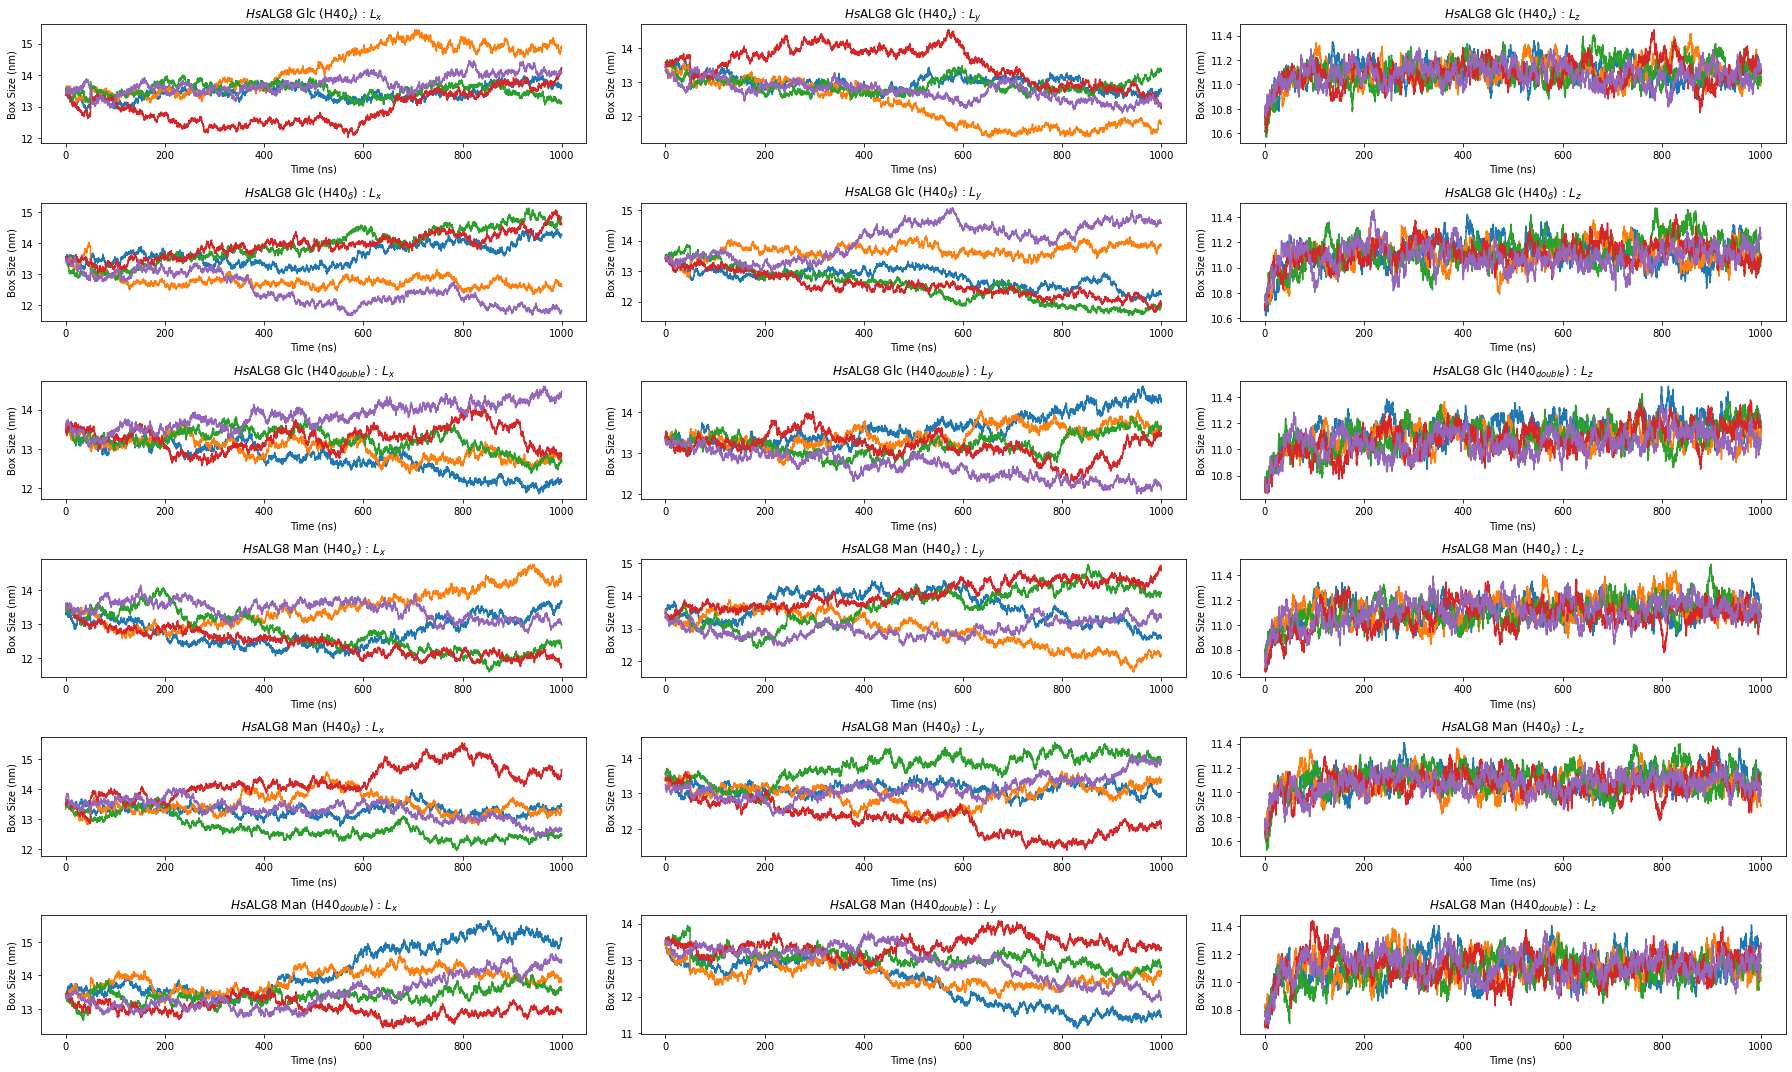

In [27]:
fig, axs = plt.subplots(6, 3, figsize=(25, 15))
for i_mutation, mutation in enumerate(mutations):
    ax = axs[i_mutation]
    title = f"Box Vectors for {mutation} in {state} State"
    for run in range(1, runs + 1):
        test_file = f"./lipid_buckling/box_vectors_{state}_ALG8_{state}_{mutation}_{run}.dat"
        df = np.loadtxt(test_file, skiprows=1)
        dx, dy, dz = df[:5000, 1], df[:5000, 5], df[:5000, 9]
        t = np.arange(len(dx)) * dt
        # Plotting
        ax[0].plot(t, dx/10)
        ax[1].plot(t, dy/10)
        ax[2].plot(t, dz/10)
        # labels and titles
        ax[0].set_ylabel("Box Size (nm)")
        ax[1].set_ylabel("Box Size (nm)")
        ax[2].set_ylabel("Box Size (nm)")
        ax[0].set_xlabel("Time (ns)")
        ax[1].set_xlabel("Time (ns)")
        ax[2].set_xlabel("Time (ns)")
        ax[0].set_title(f"{object_names[i_mutation]} : "+r"$L_x$")
        ax[1].set_title(f"{object_names[i_mutation]} : "+r"$L_y$")
        ax[2].set_title(f"{object_names[i_mutation]} : "+r"$L_z$")
plt.tight_layout()
filename = f"{Figdir}box_vectors_{state}.png"
plt.savefig(filename, dpi=300)

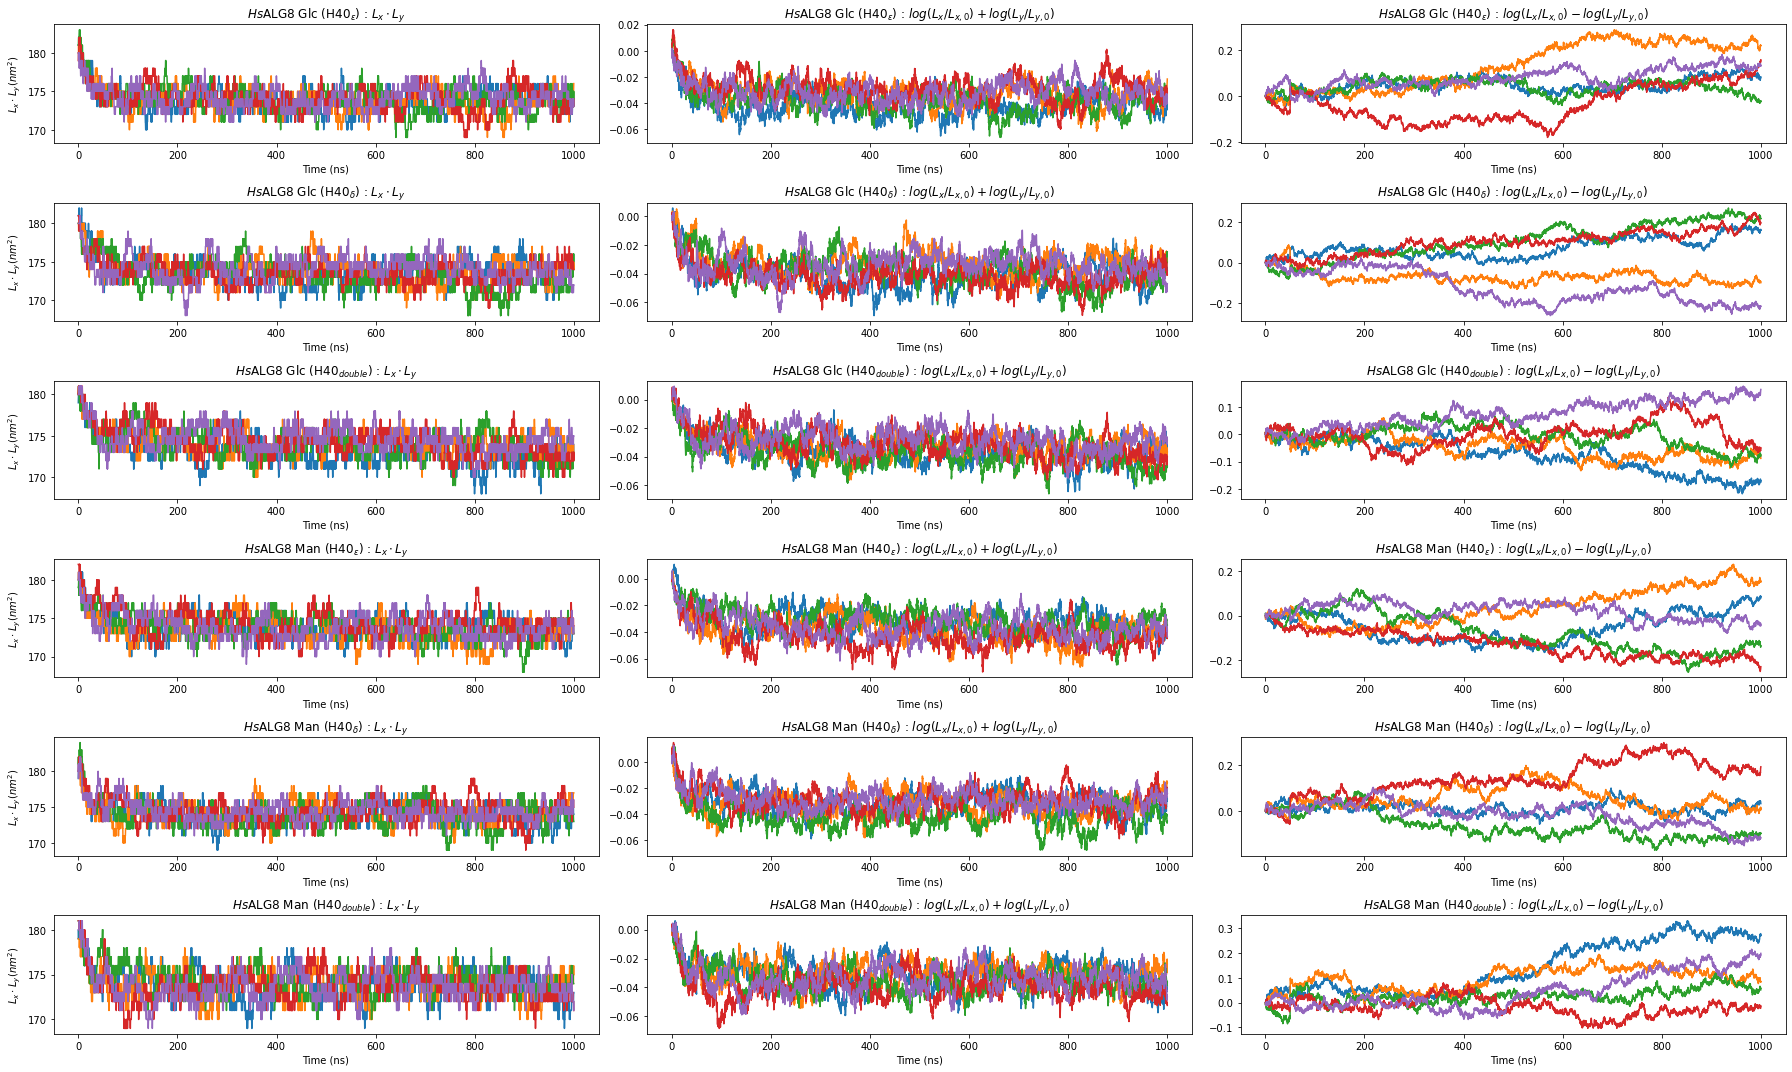

In [28]:
# analysis/lipid_buckling/box_vectors_posttransfer_ALG8_N36_post_transfer_3.dat
fig, axs = plt.subplots(6, 3, figsize=(25, 15))
for i_mutation, mutation in enumerate(mutations):
    ax = axs[i_mutation]
    title = f"Box Vectors for {mutation} in {state} State"
    for run in range(1, runs + 1):
        test_file = f"./lipid_buckling/box_vectors_{state}_ALG8_{state}_{mutation}_{run}.dat"
        df = np.loadtxt(test_file, skiprows=1)
        dx, dy, dz = df[:5000, 1], df[:5000, 5], df[:5000, 9]
        A = dx * dy
        eps_x = np.log(dx / dx[0])
        eps_y = np.log(dy / dy[0])
        eps_A = eps_x + eps_y
        q     = eps_x - eps_y
        t = np.arange(len(dx)) * dt
        # Plotting
        ax[0].plot(t, A//100) # convert to nm^2
        ax[1].plot(t, eps_A)
        ax[2].plot(t, q)
        # labels and titles
        ax[0].set_xlabel("Time (ns)")
        ax[1].set_xlabel("Time (ns)")
        ax[2].set_xlabel("Time (ns)")
        ax[0].set_ylabel(r"$L_x \cdot L_y (nm^2)$")
        ax[0].set_title(f"{object_names[i_mutation]} : "+r"$L_x \cdot L_y$")
        ax[1].set_title(f"{object_names[i_mutation]} : "+r"$log(L_x/L_{x,0}) + log(L_y/L_{y,0})$")
        ax[2].set_title(f"{object_names[i_mutation]} : "+r"$log(L_x/L_{x,0}) - log(L_y/L_{y,0})$")
plt.tight_layout()
filename = f"{Figdir}box_vectors_{state}_area_strain.png"
plt.savefig(filename, dpi=300)

In [29]:
# Post-transfer Analysis

In [30]:
mutations = ['N36', 'D36', 'N36_H40d', 'D36_H40d', 'N36_H40db', 'D36_H40db']
object_names = [r'$Hs$ALG8 D36 (H40$_{\epsilon}$)', r'$Hs$ALG8 D36 (H40$_{\delta}$)', r'$Hs$ALG8 D36 (H40$_{double}$)',
                r'$Hs$ALG8 N36 (H40$_{\epsilon}$)', r'$Hs$ALG8 N36 (H40$_{\delta}$)', r'$Hs$ALG8 N36 (H40$_{double}$)',
                ]
state = "post_transfer"

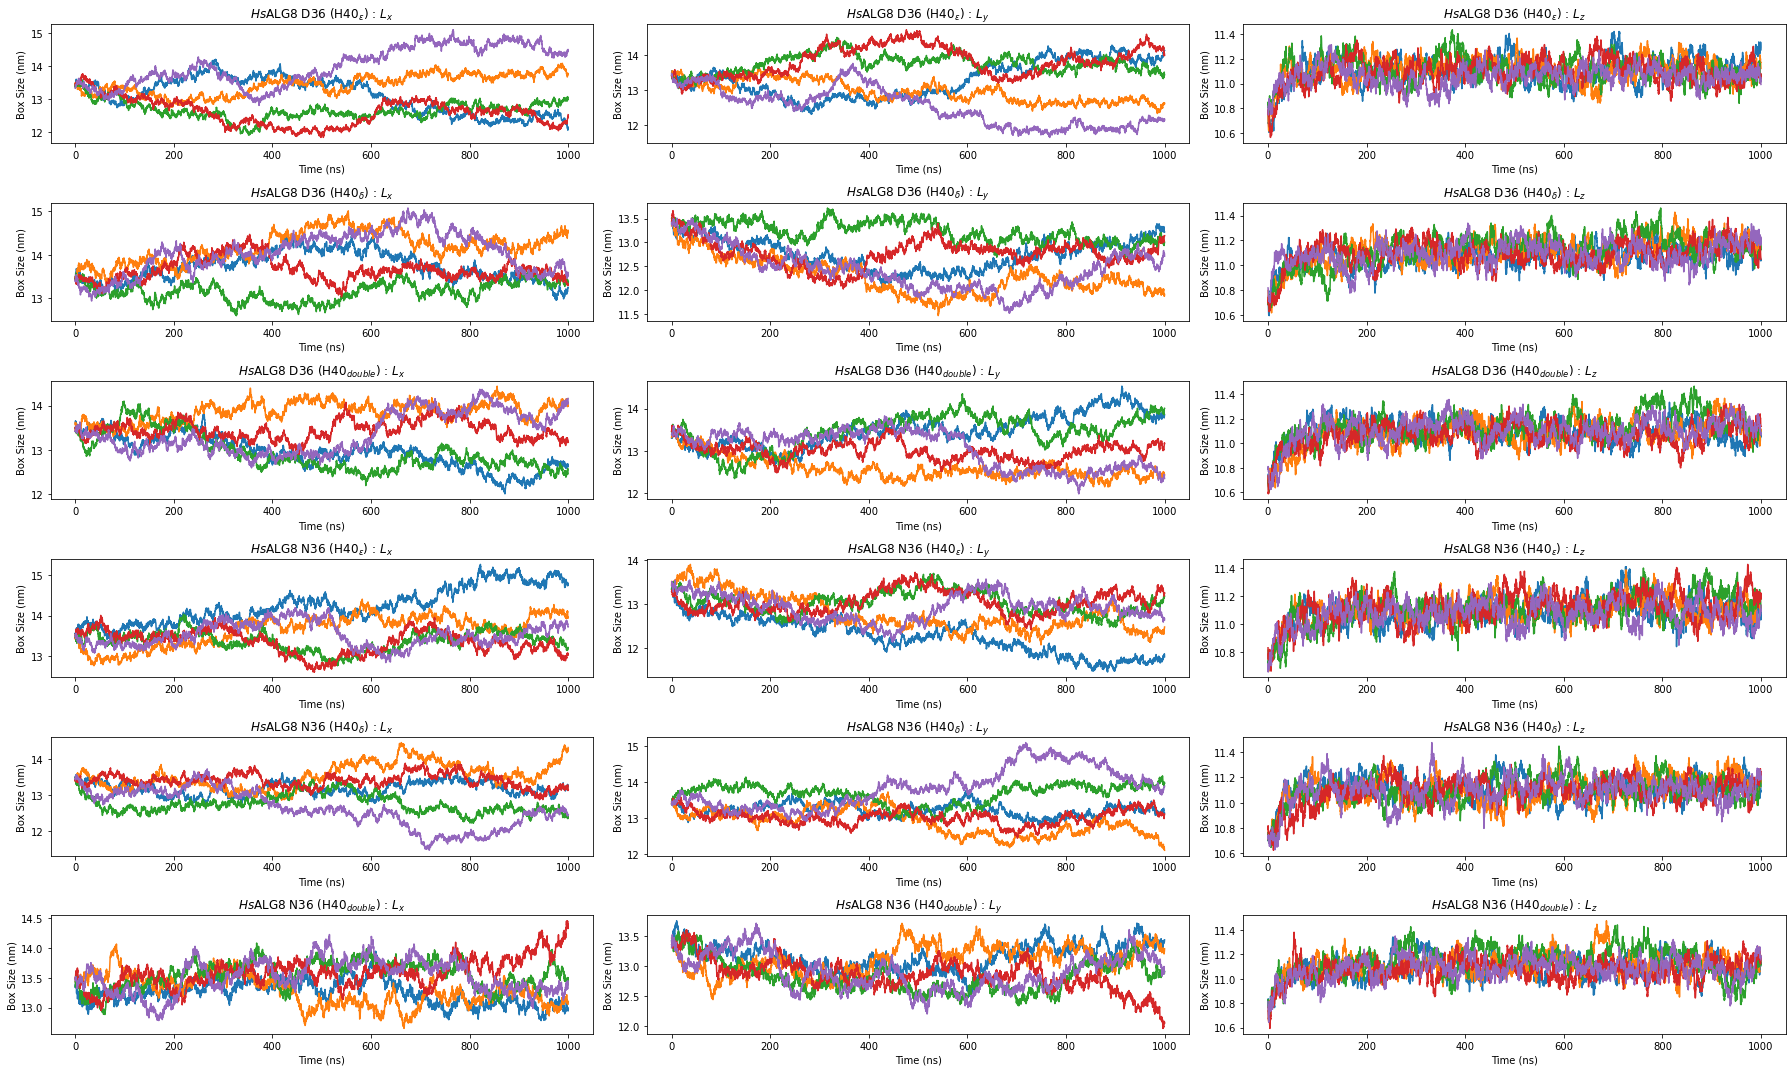

In [31]:
fig, axs = plt.subplots(6, 3, figsize=(25, 15))
for i_mutation, mutation in enumerate(mutations):
    ax = axs[i_mutation]
    title = f"Box Vectors for {mutation} in {state} State"
    for run in range(1, runs + 1):
        test_file = f"./lipid_buckling/box_vectors_posttransfer_ALG8_{mutation}_{state}_{run}.dat"
        df = np.loadtxt(test_file, skiprows=1)
        dx, dy, dz = df[:5000, 1], df[:5000, 5], df[:5000, 9]
        t = np.arange(len(dx)) * dt
        # Plotting
        ax[0].plot(t, dx/10)
        ax[1].plot(t, dy/10)
        ax[2].plot(t, dz/10)
        # labels and titles
        ax[0].set_ylabel("Box Size (nm)")
        ax[1].set_ylabel("Box Size (nm)")
        ax[2].set_ylabel("Box Size (nm)")
        ax[0].set_xlabel("Time (ns)")
        ax[1].set_xlabel("Time (ns)")
        ax[2].set_xlabel("Time (ns)")
        ax[0].set_title(f"{object_names[i_mutation]} : "+r"$L_x$")
        ax[1].set_title(f"{object_names[i_mutation]} : "+r"$L_y$")
        ax[2].set_title(f"{object_names[i_mutation]} : "+r"$L_z$")
plt.tight_layout()
filename = f"{Figdir}box_vectors_{state}.png"
plt.savefig(filename, dpi=300)

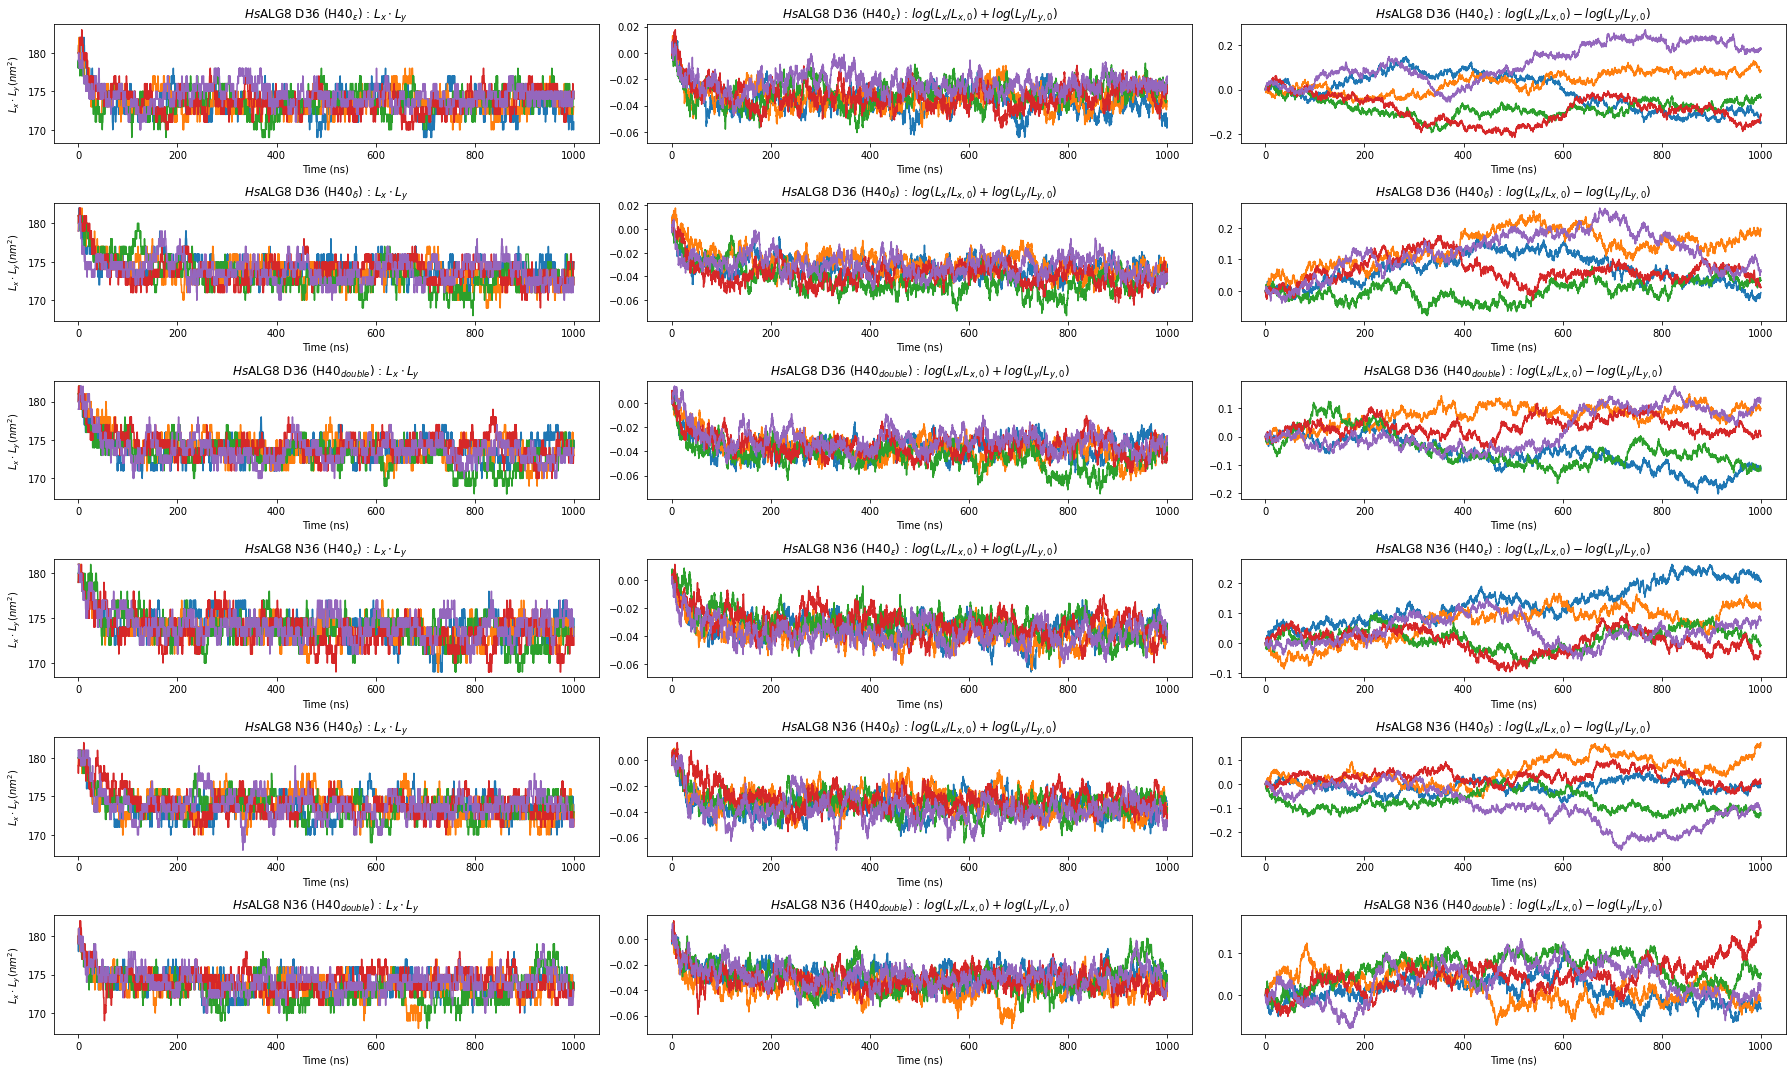

In [32]:
fig, axs = plt.subplots(6, 3, figsize=(25, 15))
for i_mutation, mutation in enumerate(mutations):
    ax = axs[i_mutation]
    title = f"Box Vectors for {mutation} in {state} State"
    for run in range(1, runs + 1):
        test_file = f"./lipid_buckling/box_vectors_posttransfer_ALG8_{mutation}_{state}_{run}.dat"
        df = np.loadtxt(test_file, skiprows=1)
        dx, dy, dz = df[:5000, 1], df[:5000, 5], df[:5000, 9]
        A = dx * dy
        eps_x = np.log(dx / dx[0])
        eps_y = np.log(dy / dy[0])
        eps_A = eps_x + eps_y
        q     = eps_x - eps_y
        t = np.arange(len(dx)) * dt
        # Plotting
        ax[0].plot(t, A//100) # convert to nm^2
        ax[1].plot(t, eps_A)
        ax[2].plot(t, q)
        # labels and titles
        ax[0].set_xlabel("Time (ns)")
        ax[1].set_xlabel("Time (ns)")
        ax[2].set_xlabel("Time (ns)")
        ax[0].set_ylabel(r"$L_x \cdot L_y (nm^2)$")
        ax[0].set_title(f"{object_names[i_mutation]} : "+r"$L_x \cdot L_y$")
        ax[1].set_title(f"{object_names[i_mutation]} : "+r"$log(L_x/L_{x,0}) + log(L_y/L_{y,0})$")
        ax[2].set_title(f"{object_names[i_mutation]} : "+r"$log(L_x/L_{x,0}) - log(L_y/L_{y,0})$")
plt.tight_layout()
filename = f"{Figdir}box_vectors_{state}_area_strain.png"
plt.savefig(filename, dpi=300)